# Проект: Исследование финансирования стартапов

- Автор: Гусев Александр Олегович

## Введение

**Цель проекта** — изучить динамику финансирования стартапов, выявить ключевые тенденции и аномалии. Особое внимание уделяется анализу размеров финансирования по годам, раундам и категориям компаний, а также исследованию факторов, влияющих на успешность стартапов, включая образование сотрудников и статус компаний.

В ходе проекта планируется предобработать данные, объединить таблицы и провести исследовательский анализ. Это позволит определить типичные размеры инвестиций, выявить выбросы и аномальные случаи, а также дать рекомендации по улучшению стратегии инвестирования.


## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
* `acquisition.csv`
* `company_and_rounds.csv`
* `degrees.csv`
* `education.csv`
* `fund.csv`
* `investment.csv`
* `people.csv`

Они находятся в папке datasets, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации, исправление названия столбцов

* Загрузите все данные по проекту.

* Проверьте названия столбцов и есть ли в датасетах полные дубликаты строк.

* Выведите информацию, которая необходима вам для принятия решений о предобработке, для каждого из датасетов.

Загрузим необходимые библиотеки и наши датасеты. После этого проведем первичный анализ датасетов.

In [1]:
# Импортируем библиотеки для работы
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Выгружаем все наши датасеты в переменные
acquisition_df = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
company_and_rounds_df = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
degrees_df = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')
education_df = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
fund_df = pd.read_csv('https://code.s3.yandex.net/datasets/fund.csv')
investment_df = pd.read_csv('https://code.s3.yandex.net/datasets/investment.csv')
people_df = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')

In [3]:
# Просмотрим информацию по каждому датасету
acquisition_df.info()
acquisition_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


`acquisition`:

Размеры: 9407 строк, 6 столбцов.
Содержит информацию о сделках приобретения между компаниями.
Необходимо изменение формата столбцов:
- `acquired_at` → datetime (дата сделки)

In [4]:
company_and_rounds_df.info()
company_and_rounds_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217472 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nul

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`company_and_rounds`:

Размеры: 217774 строки, 22 столбца. Информация о компаниях и раундах финансирования.
Сразу заметно большое количество пропусков.

Изменение форматов:
- `founded at`, `closed at`, `funded at` → datetime (даты событий)

Также необходимо приведение к типу snake case.

In [5]:
degrees_df.info()
degrees_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


`degrees`:

Размеры: 109610 строк, 4 столбца. Данные об образовании сотрудников.

In [6]:
education_df.info()
education_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


`education`:

Размеры: 109610 строк, 4 столбца. Сведения об образовании сотрудников (учебное заведение, дата выпуска).

Изменение форматов:
`graduated_at` → datetime (дата выпуска).

In [7]:
fund_df.info()
fund_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11652 entries, 0 to 11651
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  11652 non-null  int64 
 1   name                11650 non-null  object
 2   founded_at          4605 non-null   object
 3   domain              7362 non-null   object
 4   network_username    2149 non-null   object
 5   country_code        7053 non-null   object
 6   investment_rounds   11652 non-null  int64 
 7   invested_companies  11652 non-null  int64 
 8   milestones          11652 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 819.4+ KB


,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaN,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaN,NaN,NaN,NaN,0,0,1


`fund`:

Размеры: 11652 строки, 9 столбцов. Информация о фондах.

`founded_at` → datetime (дата создания фонда).

In [8]:
investment_df.info()
investment_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61403 entries, 0 to 61402
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                61403 non-null  int64
 1   funding_round_id  61403 non-null  int64
 2   company_id        61403 non-null  int64
 3   fund_id           61403 non-null  int64
dtypes: int64(4)
memory usage: 1.9 MB


,id,funding_round_id,company_id,fund_id
0,1,1,4,1
1,2,1,4,2
2,3,3,5,4
3,4,4,5,1
4,5,4,5,5


`investment`:

Размеры: 61403 строки, 4 столбца. Данные о раундах финансирования.

Изменения форматов не требуются.

In [9]:
people_df.info()
people_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


`people`:

Размеры: 226709 строк, 5 столбцов. Информация о сотрудниках компаний.

Изменение форматов не требуется.

**Промежуточный результат:**
- загрузили нужные библиотеки и датасеты,
- провели первичный анализ, который показал:
    - потребуется изменение форматов столбцов, названий столбцов.
    - также вызывает вопросы дублирующийся столбец в `company_and_rounds_df`, нужно будет с ним разобраться
    - сразу заметно приличное количество пропусков, в дальнейшем нужно будет обратить на них внимание.

### 1.2 **Работа с явными дубликатами и нормализация названий столбцов**

**COMPANY_AND_ROUNDS**

- Для начала проверим теорию. Датасет `company_and_rounds_df` содержит два столбца с очень похожими значениями и названиями: `company  ID`, `company  id`. Проверим, дублирует ли один столбец другой. 

In [10]:
# Проверка, есть ли расхождения между значениями двух столбцов
if 'company  ID' in company_and_rounds_df.columns and 'company  id' in company_and_rounds_df.columns:
    # Удаляем строки, где хотя бы одно из значений равно NaN
    non_nan_data = company_and_rounds_df.dropna(subset=['company  ID', 'company  id'], how='any')
    
    # Проверяем строки, где значения в обоих столбцах не равны
    conflicting_values = non_nan_data[non_nan_data['company  ID'] != non_nan_data['company  id']]
    
    # Вывод результатов
    if conflicting_values.empty:
        display("Все значения совпадают, если оба столбца не NaN.")
    else:
        display(f"Обнаружено {conflicting_values.shape[0]} строк с расхождениями.")
        display(conflicting_values.head(10))  # Пример конфликтующих строк
else:
    display("Значения не совпадают.")

'Все значения совпадают, если оба столбца не NaN.'

- Как и ожидалось, все значения, кроме пропусков, совпадают. Значит можем смело удалить один из них.

In [11]:
# Объединение значений из двух столбцов и удаление второго
company_and_rounds_df['company  ID'] = company_and_rounds_df['company  ID'].fillna(company_and_rounds_df['company  id'])
company_and_rounds_df = company_and_rounds_df.drop(columns=['company  id'])

company_and_rounds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217774 non-null  float64
 1   name                   217472 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  funded  at             52680 non-nul

In [12]:
# Приведение названий столбцов к snake_case
company_and_rounds_df.columns = company_and_rounds_df.columns.str.lower().str.replace(' ', '_')

# Замена двойных подчёркиваний на одиночные
company_and_rounds_df.columns = company_and_rounds_df.columns.str.replace('__', '_')

# Проверка и удаление полных дубликатов строк
duplicates_company_and_rounds_df = company_and_rounds_df.duplicated().sum()
company_and_rounds_df = company_and_rounds_df.drop_duplicates()

# Результаты
display(f'company_and_rounds_df: Полных дубликатов удалено: {duplicates_company_and_rounds_df}')
company_and_rounds_df.info()
company_and_rounds_df.head()

'company_and_rounds_df: Полных дубликатов удалено: 0'

<class 'pandas.core.frame.DataFrame'>
Int64Index: 217774 entries, 0 to 217773
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   company_id           217774 non-null  float64
 1   name                 217472 non-null  object 
 2   category_code        143886 non-null  object 
 3   status               217472 non-null  object 
 4   founded_at           109956 non-null  object 
 5   closed_at            3449 non-null    object 
 6   domain               147159 non-null  object 
 7   network_username     95534 non-null   object 
 8   country_code         108607 non-null  object 
 9   investment_rounds    217472 non-null  float64
 10  funding_rounds       217472 non-null  float64
 11  funding_total        217472 non-null  float64
 12  milestones           217472 non-null  float64
 13  funding_round_id     52928 non-null   float64
 14  funded_at            52680 non-null   object 
 15  funding_round_typ

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,funding_total,milestones,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,39750000.0,5.0,888.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,39750000.0,5.0,889.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,39750000.0,5.0,2312.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,0.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Результат обработки company_and_rounds_df:**
- удалили дублирующий столбец, вероятно возникший при предыдущем объединении таблиц,
- проверили на явные дубликаты, их оказалось 0,
- привели названия столбцов к единому стилю.

**Также проверим оставшиеся датасеты на дубликаты и приведем названия столбцов к единому стилю:**

In [13]:
def process_dataset(df):
    # Приведение названий столбцов к единому стилю
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    
    # Проверка и удаление полных дубликатов строк
    duplicates = df.duplicated().sum()
    df = df.drop_duplicates()

    # Вывод информации
    print(f"Полных дубликатов удалено: {duplicates}")
    print(f"Обновленные столбцы: {df.columns}")
    display(df.head())
    
    return df

# Обработка каждого датасета
acquisition_df = process_dataset(acquisition_df)
investment_df = process_dataset(investment_df)
people_df = process_dataset(people_df)
fund_df = process_dataset(fund_df)
degrees_df = process_dataset(degrees_df)
education_df = process_dataset(education_df)

Полных дубликатов удалено: 0
Обновленные столбцы: Index(['id', 'acquiring_company_id', 'acquired_company_id', 'term_code',
       'price_amount', 'acquired_at'],
      dtype='object')


,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


Полных дубликатов удалено: 0
Обновленные столбцы: Index(['id', 'funding_round_id', 'company_id', 'fund_id'], dtype='object')


,id,funding_round_id,company_id,fund_id
0,1,1,4,1
1,2,1,4,2
2,3,3,5,4
3,4,4,5,1
4,5,4,5,5


Полных дубликатов удалено: 0
Обновленные столбцы: Index(['id', 'first_name', 'last_name', 'company_id', 'network_username'], dtype='object')


...

,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaN,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaN,NaN,NaN,NaN,0,0,1


Полных дубликатов удалено: 0
Обновленные столбцы: Index(['id', 'object_id', 'degree_type', 'subject'], dtype='object')


,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


Полных дубликатов удалено: 0
Обновленные столбцы: Index(['id', 'person_id', 'instituition', 'graduated_at'], dtype='object')


,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


**Промежуточные результаты:**
- во всех таблицах не обнаружено явных дубликатов,
- все названия столбцов приведены к стилю snake case,
- в таблице `company_and_rounds.csv` удален задублированный столбец.

### 1.2. Смена типов и анализ пропусков

* Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

* Оцените полноту данных — сделайте предварительный вывод, достаточно ли данных для решения задач проекта.

- Сперва проведем работу с датасетом `company_and_rounds_df`, преобразуем формат дат в корректный и посчитаем процент пропусков

In [14]:
# Преобразование столбцов с датами
company_and_rounds_df['founded_at'] = pd.to_datetime(company_and_rounds_df['founded_at'], errors='coerce')
company_and_rounds_df['closed_at'] = pd.to_datetime(company_and_rounds_df['closed_at'], errors='coerce')
company_and_rounds_df['funded_at'] = pd.to_datetime(company_and_rounds_df['funded_at'], errors='coerce')

# Оценка пропусков
print("Пропуски в столбцах:")
display(company_and_rounds_df.isnull().mean() * 100)
company_and_rounds_df.info()
company_and_rounds_df.sample(3, random_state=551).T

Пропуски в столбцах:


company_id              0.000000
name                    0.138676
category_code          33.928752
status                  0.138676
founded_at             49.509124
closed_at              98.416248
domain                 32.425818
network_username       56.131586
country_code           50.128574
investment_rounds       0.138676
funding_rounds          0.138676
funding_total           0.138676
milestones              0.138676
funding_round_id       75.695905
funded_at              75.809784
funding_round_type     75.695905
raised_amount          75.695905
pre_money_valuation    75.695905
participants           75.695905
is_first_round         75.695905
is_last_round          75.695905
dtype: float64

<class 'pandas.core.frame.DataFrame'>
Int64Index: 217774 entries, 0 to 217773
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id           217774 non-null  float64       
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

,49014,10445,45605
company_id,185110.0,143369.0,181736.0
name,Celaton,GBSA Int. Investment Group,Wheelhouse Apartment
category_code,software,NaN,NaN
status,operating,operating,operating
founded_at,NaT,NaT,NaT
closed_at,NaT,NaT,NaT
domain,celaton.com,NaN,wheelhouseapartments.com.au
network_username,celaton,NaN,NaN
country_code,GBR,NaN,NaN
investment_rounds,0.0,1.0,0.0


- Нормализуем столбцы с датами в оставшихся датасетах, где они присутствуют.

In [16]:
# 1. Acquisition
acquisition_df['acquired_at'] = pd.to_datetime(acquisition_df['acquired_at'], errors='coerce')

# 2. Fund
fund_df['founded_at'] = pd.to_datetime(fund_df['founded_at'], errors='coerce')

# 3. Education
education_df['graduated_at'] = pd.to_datetime(education_df['graduated_at'], errors='coerce')

# Проверка результатов для всех датасетов
display('Acquisition')
display(acquisition_df.info())

display('Fund')
display(fund_df.info())

display('Education')
display(education_df.info())

'Acquisition'

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9407 non-null   int64         
 1   acquiring_company_id  9407 non-null   int64         
 2   acquired_company_id   9407 non-null   int64         
 3   term_code             1831 non-null   object        
 4   price_amount          9407 non-null   int64         
 5   acquired_at           9378 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 514.4+ KB


None

'Fund'

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11652 entries, 0 to 11651
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  11652 non-null  int64         
 1   name                11650 non-null  object        
 2   founded_at          4605 non-null   datetime64[ns]
 3   domain              7362 non-null   object        
 4   network_username    2149 non-null   object        
 5   country_code        7053 non-null   object        
 6   investment_rounds   11652 non-null  int64         
 7   invested_companies  11652 non-null  int64         
 8   milestones          11652 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 910.3+ KB


None

'Education'

<class 'pandas.core.frame.DataFrame'>
Int64Index: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            109610 non-null  int64         
 1   person_id     109610 non-null  int64         
 2   instituition  109555 non-null  object        
 3   graduated_at  58054 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 4.2+ MB


None

- Используем функцию, чтобы посчитать процент пропусков в каждом датасете

In [17]:
# Функция для анализа пропусков
def analyze_missing_values(df, dataset_name):
    """
    Выводит процент пропусков в каждом столбце датафрейма.
    Если пропусков нет, выводит сообщение об их отсутствии.
    """
    missing_values = df.isnull().mean() * 100
    missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
    
    print(f"\n=== Пропуски в {dataset_name} ===")
    if missing_values.empty:
        print(f"В датафрейме '{dataset_name}' пропусков нет.")
    else:
        print(missing_values)
    return missing_values

# Анализ пропусков для всех датасетов
acquisition_missing = analyze_missing_values(acquisition_df, "Acquisition")
investment_missing = analyze_missing_values(investment_df, "Investment")
people_missing = analyze_missing_values(people_df, "People")
fund_missing = analyze_missing_values(fund_df, "Fund")
degrees_missing = analyze_missing_values(degrees_df, "Degrees")
education_missing = analyze_missing_values(education_df, "Education")
company_and_rounds_missing = analyze_missing_values(company_and_rounds_df, "Company_and_rounds")

# Объединение результатов в таблицу
missing_summary = {
    "Acquisition": acquisition_missing,
    "Investment": investment_missing,
    "People": people_missing,
    "Fund": fund_missing,
    "Degrees": degrees_missing,
    "Education": education_missing,
    "Company_and_rounds": company_and_rounds_missing,
}


=== Пропуски в Acquisition ===
term_code      80.535771
acquired_at     0.308281
dtype: float64

=== Пропуски в Investment ===
В датафрейме 'Investment' пропусков нет.

=== Пропуски в People ===
company_id          84.731528
network_username    82.855996
first_name           0.002205
last_name            0.000441
dtype: float64

=== Пропуски в Fund ===
network_username    81.556814
founded_at          60.478888
country_code        39.469619
domain              36.817714
name                 0.017164
dtype: float64

=== Пропуски в Degrees ===
subject        25.829760
degree_type    10.234468
dtype: float64

=== Пропуски в Education ===
graduated_at    47.035854
instituition     0.050178
dtype: float64

=== Пропуски в Company_and_rounds ===
closed_at              98.416248
funded_at              75.809784
is_last_round          75.695905
funding_round_type     75.695905
is_first_round         75.695905
participants           75.695905
pre_money_valuation    75.695905
raised_amount      

**Анализ причин пропусков в данных:**

1. **`Acquisition`**
- `term_code` (80.5% пропусков):
Этот столбец указывает на условия сделки (cash, stock, и т.д.).
Причина: Некоторые сделки могли быть выполнены без указания условий, или эта информация отсутствует в источнике данных.
- `acquired_at` (0.3%):
Дата сделки иногда может быть не зафиксирована, если событие не подтверждено.

3. **`People`**
- `company_id` (84.7%) и `network_username` (82.9%):
Эти столбцы связаны с привязкой сотрудников к компаниям и социальным сетям.
Причина:
Большинство сотрудников могли быть не привязаны к конкретной компании.
- `network_username` — дополнительная информация, которая часто остаётся незаполненной, так как не все сотрудники имеют публичные аккаунты или информация не была собрана.
- `first_name` и `last_name`: минимальные пропуски — возможные ошибки в данных или редкие случаи неполной информации.

3. **`Fund`**
- `network_username` (81.6%) и `domain` (36.8%):
Причина: Не все фонды имеют сайт или сетевое имя.
- `founded_at` (60.5%):
Дата основания могла быть утеряна или отсутствовать для старых фондов.
- `country_code` (39.5%):
Отсутствие информации о стране может быть связано с недостаточной детализацией источника данных.

4. **`Degrees`**
- `subject` (25.8%):
Специальность сотрудника часто не указывается или не собирается.
- `degree_type` (10.2%):
Тип образования может быть утерян для старых записей.

5. **`Education`**
- `graduated_at` (47.0%):
Для старых сотрудников дата окончания учебного заведения могла быть неизвестной или не зафиксированной.
- `instituition` (0.05%):
Небольшие пропуски могут быть вызваны ошибками в данных.

6. **`Company_and_rounds`**
- `closed_at` (98.4%):
Почти все компании не имеют даты закрытия.
Причина: Большинство компаний продолжают работать, а значит, дата закрытия отсутствует.
- `funded_at`, `is_first_round`, `participants`, `pre_money_valuation` (~75.7%):
Эти данные связаны с раундами финансирования.
Пропуски могут быть вызваны тем, что:
- Не для всех компаний фиксируется информация по финансированию.
- Данные могли быть частично утеряны при сборе из разных источников.

- `network_username` (56.1%) и `founded_at` (49.5%):
Информация по социальным профилям и датам основания могла отсутствовать для старых компаний.
- `category_code` (33.9%):
Не для всех компаний определена категория.

**Общие выводы по пропускам:**
Источники данных:
Пропуски возникают из-за неполных источников информации. Например, старые записи могут не содержать всех атрибутов.

Дополнительные данные:
Поля, такие как `network_username`, `subject`, и `pre_money_valuation`, часто являются вторичными и не всегда заполняются.

Отсутствие событий:
Поля вроде `closed_at` или `funded_at` могут отсутствовать, если событие (закрытие компании или финансирование) не произошло.

Сбор данных:
Объединение из разных таблиц (например, `company_and_rounds`) могло привести к пропускам, если информация отсутствовала в одном из источников.

**Промежуточный итог:**

- `Investment` — полностью готов для анализа.
- `Acquisition` и `Degrees` — данные достаточно полные для базового анализа.
- `Fund` и `Education` — требуют осторожности при анализе из-за большого количества пропусков.
- `People` и `Company_and_rounds` — пропуски значительны в ключевых столбцах. Для решения задач потребуется учитывать это в дальнейшем.
На данном этапе не будем удалять их или заменять, чтобы не нарушить структуру данных.

## Шаг 2. Предобработка данных, предварительное исследование

### 2.1. Объединять или не объединять — вот в чём вопрос

Некоторые названия столбцов встречаются в датасетах чаще других. И, например, в результате предварительной проверки датасетов было выяснено, что столбец `company_id` подходит для объединения данных, так как большая часть значений встречается в разных датасетах не один, а несколько раз. Этот столбец может быть использован для объединения данных.

* Установите, подходит ли для объединения данных столбец `network_username`, который встречается в нескольких датасетах. Нам необходимо понимать, дублируется ли для разных датасетов информация в столбцах с таким названием, и если да — то насколько часто.

* Оцените, можно ли использовать столбцы с именем `network_username` для объединения данных.

In [18]:
# Проверка наличия столбца 'network_username' в датасетах
datasets = {
    "People": people_df,
    "Fund": fund_df,
    "Company_and_rounds": company_and_rounds_df
}

# Анализ network_username
print("=== Анализ network_username в каждом датасете ===")
for name, df in datasets.items():
    if 'network_username' in df.columns:
        total_values = df['network_username'].shape[0]
        unique_values = df['network_username'].nunique()
        missing_values = df['network_username'].isnull().sum()
        missing_percentage = round(missing_values / total_values * 100, 2)
        
        display(f"{name}:")
        display(f"  - Всего строк: {total_values}")
        display(f"  - Уникальные значения: {unique_values}")
        display(f"  - Пропуски: {missing_values} ({missing_percentage}%)")
        print("-" * 30)

# Поиск пересечений значений network_username между датасетами
people_networks = set(people_df['network_username'].dropna()) if 'network_username' in people_df.columns else set()
fund_networks = set(fund_df['network_username'].dropna()) if 'network_username' in fund_df.columns else set()
company_networks = set(company_and_rounds_df['network_username'].dropna()) if 'network_username' in company_and_rounds_df.columns else set()

# Оценка пересечений
intersection_people_fund = len(people_networks.intersection(fund_networks))
intersection_people_company = len(people_networks.intersection(company_networks))
intersection_fund_company = len(fund_networks.intersection(company_networks))

# Вывод результатов пересечений
print("\n=== Пересечения значений network_username между датасетами ===")
display(f"People & Fund: {intersection_people_fund} общих значений")
display(f"People & Company_and_rounds: {intersection_people_company} общих значений")
display(f"Fund & Company_and_rounds: {intersection_fund_company} общих значений")

=== Анализ network_username в каждом датасете ===


'People:'

'  - Всего строк: 226709'

'  - Уникальные значения: 38421'

'  - Пропуски: 187842 (82.86%)'

...

'  - Пропуски: 122240 (56.13%)'

------------------------------

=== Пересечения значений network_username между датасетами ===


'People & Fund: 79 общих значений'

'People & Company_and_rounds: 2199 общих значений'

'Fund & Company_and_rounds: 70 общих значений'

**Результаты анализа `network_username`:**
Общее количество значений и пропусков:

- `People`:
Всего строк: 226,709.
Уникальные значения: 38,421.
Пропуски: 187,842 (82.9%).

- `Fund`:
Всего строк: 11,652.
Уникальные значения: 2,098.
Пропуски: 9,503 (81.6%).

- `Company_and_rounds`:
Всего строк: 217,774.
Уникальные значения: 79,571.
Пропуски: 122,240 (56.13%).

*Пересечения значений:*

- `People` и `Fund`: 79 общих значений.
- `People` и `Company_and_rounds`: 2199 общих значений.
- `Fund` и `Company_and_rounds`: 70 общих значений.

Вывод:
`network_username` имеет небольшие пересечения между `People` и `Fund` (всего 79 значений).
Между `Company_and_rounds`, `People` и `Fund` данный столбец имеет 2199 и 70 пересечений.
Из-за большого количества пропусков и слабого пересечения между датасетами столбец `network_username` не подходит для объединения данных.

- Проверим столбец `company_id` на пригодность для объединения:

In [19]:
# Анализ уникальных значений и пропусков для company_id
datasets = {
    "Investment": investment_df,
    "People": people_df,
    "Company_and_rounds": company_and_rounds_df
}

print("=== Анализ company_id в каждом датасете ===")
for name, df in datasets.items():
    column_name = 'company_id'
    if column_name in df.columns:
        total_rows = len(df)
        unique_values = df[column_name].nunique()
        missing_values = df[column_name].isnull().sum()
        missing_percentage = round(missing_values / total_rows * 100, 2)
        
        display(f"{name}:")
        display(f"  - Всего строк: {total_rows}")
        display(f"  - Уникальные значения: {unique_values}")
        display(f"  - Пропуски: {missing_values} ({missing_percentage}%)")
        print("-" * 30)

# Пересечения company_id между датасетами
investment_ids = set(investment_df['company_id'].dropna().astype(int))
people_ids = set(people_df['company_id'].dropna().astype(int))
company_rounds_ids = set(company_and_rounds_df['company_id'].dropna().astype(int))

# Оценка пересечений
intersection_investment_people = len(investment_ids.intersection(people_ids))
intersection_investment_rounds = len(investment_ids.intersection(company_rounds_ids))
intersection_people_rounds = len(people_ids.intersection(company_rounds_ids))

# Вывод результатов пересечений
print("\n=== Пересечения значений company_id между датасетами ===")
display(f"Investment & People: {intersection_investment_people} общих значений")
display(f"Investment & Company_and_rounds: {intersection_investment_rounds} общих значений")
display(f"People & Company_and_rounds: {intersection_people_rounds} общих значений")

=== Анализ company_id в каждом датасете ===


'Investment:'

'  - Всего строк: 61403'

'  - Уникальные значения: 17991'

'  - Пропуски: 0 (0.0%)'

...

'  - Пропуски: 0 (0.0%)'

------------------------------

=== Пересечения значений company_id между датасетами ===


'Investment & People: 4131 общих значений'

'Investment & Company_and_rounds: 17991 общих значений'

'People & Company_and_rounds: 22922 общих значений'

**Результаты анализа `company_id`:**
Общее количество строк, уникальных значений и пропусков:

- `Investment`:
Всего строк: 61,403.
Уникальные значения: 17,991.
Пропусков: 0%.

- `People`:
Всего строк: 226,709.
Уникальные значения: 22,922.
Пропусков: 84.73% строк.

- `Company_and_rounds`:
Всего строк: 217,774.
Уникальные значения: 196,785.
Пропусков: 0%.

*Пересечения значений:*

- `Investment` & `People`: 4,131 общих значений.
- `Investment` & `Company_and_rounds`: 17,991 общих значений.
- `People` & `Company_and_rounds`: 22,922 общих значений.

Вывод:
- Столбец `company_id` успешно пересекается между `Investment`, `People` и `Company_and_rounds`.
- `Investment` и `Company_and_rounds` имеют полное пересечение по 17,991 значению.
- `People` и `Company_and_rounds` показывают полное совпадение своих уникальных значений.

Таким образом, `company_id` можно эффективно использовать как ключ для объединения данных между этими тремя датасетами. 


### 2.2. Проблемный датасет и причина возникновения пропусков

Во время собственного анализа данных у заказчика больше всего вопросов возникло к датасету `company_and_rounds.csv`. В нём много пропусков как раз в информации о раундах, которая заказчику важна. Хотя информация об общем объёме финансирования по раундам присутствует в других датасетах, заказчик считает данные `company_and_rounds.csv` о размере средств наиболее верными.

* Любым удобным способом приведите данные в вид, который позволяет проводить анализ в разрезе отдельных компаний. Можно изменять форму данных, порядок их хранения. Обратите внимание на структуру датасета, порядок и названия столбцов, проанализируйте значения.

По гипотезе заказчика данные по компаниям из этой таблицы раньше хранились иначе, более удобным для исследования образом.

* Максимальным образом сохраняя данные, сохранив их связность и исключив возможные возникающие при этом ошибки, подготовьте данные так, чтобы удобно было отобрать компании по параметрам и рассчитать показатели из расчёта на одну компанию.

Сперва необходимо:
- преобразовать необходимые столбцы в корректные форматы

После этого агрегируем данные по `company_id`:

In [20]:
# Преобразование форматов данных
company_and_rounds_df['funding_rounds'] = company_and_rounds_df['funding_rounds'].astype('Int64')
company_and_rounds_df['investment_rounds'] = company_and_rounds_df['investment_rounds'].astype('Int64')
company_and_rounds_df['company_id'] = company_and_rounds_df['company_id'].astype('Int64')

# Агрегация данных по company_id
aggregated_data = company_and_rounds_df.groupby('company_id', as_index=False).agg({
    'name': 'first',                # Название компании
    'category_code': 'first',       # Категория компании
    'status': 'first',              # Статус компании
    'founded_at': 'min',            # Дата основания компании
    'raised_amount': 'sum',         # Суммарное привлечённое финансирование
    'funding_rounds': 'sum',        # Суммарное количество раундов финансирования
    'investment_rounds': 'sum',     # Суммарное количество инвестиционных раундов
    'funded_at': ['min', 'max'],    # Минимальная и максимальная дата финансирования
})

# Переименование столбцов для удобства
aggregated_data.columns = [
    'company_id', 'name', 'category_code', 'status', 'founded_at',
    'raised_amount', 'funding_rounds', 'investment_rounds',
    'first_funded_at', 'last_funded_at']

# Отключение научной нотации для чисел с плавающей точкой
pd.options.display.float_format = '{:.2f}'.format

# Проверка результата
aggregated_data.head()

,company_id,name,category_code,status,founded_at,raised_amount,funding_rounds,investment_rounds,first_funded_at,last_funded_at
0,1,Wetpaint,web,operating,2005-10-17,39750000.00,9,0,2005-10-01,2008-05-19
1,2,AdventNet,enterprise,operating,1996-01-01,0.00,0,0,NaT,NaT
2,3,Zoho,software,operating,2005-09-15,0.00,0,0,NaT,NaT
3,4,Digg,news,acquired,2004-10-11,45000000.00,16,0,2005-10-01,2011-07-12
4,5,Socialnet,social,ipo,2004-02-01,2425700000.00,121,33,2004-09-01,2011-01-21


In [21]:
aggregated_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196785 entries, 0 to 196784
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id         196785 non-null  int64         
 1   name               196553 non-null  object        
 2   category_code      123186 non-null  object        
 3   status             196553 non-null  object        
 4   founded_at         91227 non-null   datetime64[ns]
 5   raised_amount      196785 non-null  float64       
 6   funding_rounds     196785 non-null  Int64         
 7   investment_rounds  196785 non-null  Int64         
 8   first_funded_at    31735 non-null   datetime64[ns]
 9   last_funded_at     31735 non-null   datetime64[ns]
dtypes: Int64(2), datetime64[ns](3), float64(1), int64(1), object(3)
memory usage: 16.9+ MB


**Результаты:**

- агрегировали данные:
    - Суммарное финансирование.
    - Количество раундов.
    - Минимальные и максимальные даты финансирования.

- преобразовали данные так, что каждая строка представляет одну компанию.
- вывели итоговую таблицу.

*Итоговая таблица:*

Данные успешно агрегированы по `company_id`:
- Каждая строка представляет одну компанию.
- Рассчитаны ключевые метрики:
    - `raised_amount`: суммарное финансирование.
    - `funding_rounds`: суммарное количество раундов финансирования
    - `investment_rounds`: суммарное количество инвестиционных раундов
    - `first_funded_at` и `last_funded_at`: временные границы финансирования.


### 2.3. Раунды финансирования по годам

* Составьте сводную таблицу по годам, в которой на основании столбца `raised_amount` для каждого года указан:

  * типичный размер средств, выделяемый в рамках одного раунда;
  * общее количество раундов финансирования за этот год.

* Оставьте в таблице информацию только для тех лет, для которых есть информация о более чем 50 раундах финансирования.

* На основе получившейся таблицы постройте график, который будет отражать динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

На основе полученных данных ответьте на вопросы:

* В каком году типичный размер собранных в рамках одного раунда средств был максимален?

* Какая тенденция по количеству раундов и выделяемых в рамках каждого раунда средств наблюдалась в 2013 году?

Предстоит:
- добавить новый столбец, в котором будет только год,
- сгруппировать раунды по годам,
- рассчитать средний размер средств за раунд,
- после фильтрации построить график для анализа.

А также проведем анализ выбросов в столбце `raised_amount`.

Границы выбросов для 'raised_amount': [-9434175.00, 16380505.00]
Количество выбросов: 5400


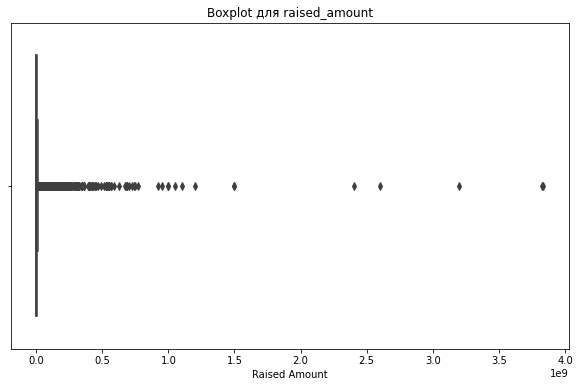

    year  raised_amount
2   2008    25000000.00
24  2013    43000000.00
79  2008    26000000.00
81  2005    17000000.00
82  2006    22000000.00


In [22]:
# Добавляем столбец 'год' на основе 'funded_at'
company_and_rounds_df['year'] = company_and_rounds_df['funded_at'].dt.year.astype('Int64')

# Функция для анализа выбросов
def detect_outliers_iqr(data, column):
    """
    Возвращает границы выбросов и сами выбросы для столбца.
    """
    Q1 = data[column].quantile(0.25)  # 25-й процентиль
    Q3 = data[column].quantile(0.75)  # 75-й процентиль
    IQR = Q3 - Q1  # Межквартильный размах
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    print(f"Границы выбросов для '{column}': [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Количество выбросов: {len(outliers)}")
    return outliers

# Анализ выбросов для 'raised_amount'
outliers_raised_amount = detect_outliers_iqr(company_and_rounds_df, 'raised_amount')

# График для визуализации выбросов
plt.figure(figsize=(10, 6))
sns.boxplot(x=company_and_rounds_df['raised_amount'])
plt.title('Boxplot для raised_amount')
plt.xlabel('Raised Amount')
plt.show()

# Вывод первых выбросов
print(outliers_raised_amount[['year', 'raised_amount']].head())

In [23]:
# Стандартная статистика по столбцу raised_amount
print("Стандартная статистика для 'raised_amount':")
print(company_and_rounds_df['raised_amount'].describe())

# Дополнительные перцентили
percentiles = [0.05, 0.25, 0.5, 0.75, 0.95]  # 5-й, 25-й, 50-й (медиана), 75-й, 95-й перцентили
print("\nПерцентили для 'raised_amount':")
print(company_and_rounds_df['raised_amount'].quantile(percentiles))

Стандартная статистика для 'raised_amount':
count        52928.00
mean       7946092.26
std       42168205.89
min              0.00
25%         246330.00
50%        1600000.00
75%        6700000.00
max     3835050000.00
Name: raised_amount, dtype: float64

Перцентили для 'raised_amount':
0.05          0.00
0.25     246330.00
0.50    1600000.00
0.75    6700000.00
0.95   29500000.00
Name: raised_amount, dtype: float64


**Выводы:**

- Данные имеют значительный разброс: большая часть значений сосредоточена на низких уровнях (медиана – 1 млн), но встречаются крупные выбросы (максимум ~3.8 млрд).
- Большое стандартное отклонение подтверждает наличие выбросов.
- Для дальнейшего анализа стоит обратить внимание на значения выше 95-го перцентиля (52 млн), так как они могут оказывать сильное влияние на среднее значение.

*Итог:*
- Используем медиану для подсчета типичного размера средств.
- Крупные выбросы не исключаем, так как их наличие еще не говорит о некорректности этих данных

In [24]:
# Группировка по годам
yearly_summary = company_and_rounds_df.groupby('year', as_index=False).agg({
    'raised_amount': 'sum',          # Сумма всех собранных средств за год
    'funding_rounds': 'sum'          # Общее количество раундов за год
})

# Проверка выбросов: используем медиану для типичного размера средств
yearly_summary['median_raised_per_round'] = company_and_rounds_df.groupby('year')['raised_amount'].median().values

# Фильтруем данные: оставляем только годы с > 50 раундами финансирования
yearly_summary = yearly_summary[yearly_summary['funding_rounds'] > 50]

# Проверка результата
yearly_summary.head(10)

,year,raised_amount,funding_rounds,median_raised_per_round
14,1998,153138990.00,72,100000.00
15,1999,563938370.00,268,2000000.00
16,2000,1435688643.00,403,4200000.00
17,2001,841105820.00,302,3000000.00
18,2002,908998728.00,385,4200000.00
19,2003,910282885.00,569,3000000.00
20,2004,2209750846.00,1057,5000000.00
21,2005,15227523397.00,4157,5500000.00
22,2006,20472795394.00,6295,5000000.00
23,2007,29285058454.00,8494,3973320.00


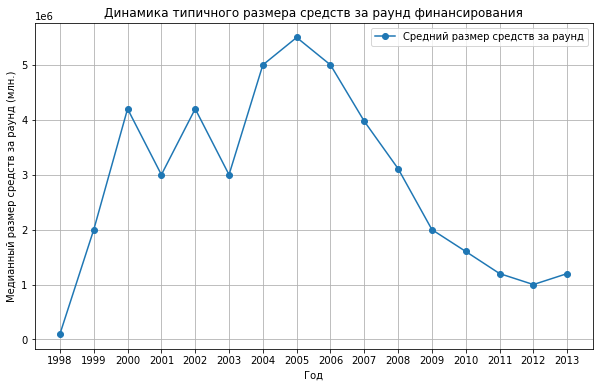

Год с максимальным типичным размером средств: 2005

2013 год:
 - Средний размер средств за раунд: 1200000.00
 - Общее количество раундов: 23978


In [25]:
# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(yearly_summary['year'], yearly_summary['median_raised_per_round'], marker='o', linestyle='-', label='Средний размер средств за раунд')
plt.title('Динамика типичного размера средств за раунд финансирования')
plt.xlabel('Год')
plt.ylabel('Медианный размер средств за раунд (млн.)')
plt.xticks(yearly_summary['year'])
plt.legend()
plt.grid()
plt.show()

# Ответы на вопросы
max_year = yearly_summary.loc[yearly_summary['median_raised_per_round'].idxmax(), 'year']
print(f"Год с максимальным типичным размером средств: {max_year}")

# Данные для 2013 года
year_2013 = yearly_summary[yearly_summary['year'] == 2013]
if not year_2013.empty:
    print(f"\n2013 год:")
    print(f" - Средний размер средств за раунд: {year_2013['median_raised_per_round'].values[0]:.2f}")
    print(f" - Общее количество раундов: {year_2013['funding_rounds'].values[0]}")

**Результаты анализа:**
- Год с максимальным типичным размером средств: 2005.
- Медианный размер средств за раунд: 5,500,000.

*Тенденция в 2013 году:*

- Средний размер средств за раунд: 1,200,000.
- Общее количество раундов: 23,978.
- В 2013 году наблюдалось уменьшение размера средств за раунд, что сопровождается значительным количеством раундов финансирования. Это говорит о высокой активности инвесторов, но средства распределялись более равномерно и в меньших объёмах по сравнению с предыдущими годами.

*Общий вывод по динамике:*
- Пик медианного размера средств наблюдался в 2005 году.
- Начиная с 2007 года наблюдается снижение размера средств за раунд.
- В 2013 году, несмотря на значительное количество раундов (23,978), средний размер средств за раунд остался на относительно низком уровне (1,200,000), что говорит о сдержанной инвестиционной политике.


### 2.4. Люди и их образование

Заказчик хочет понять, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний.

* Оцените, насколько информация об образовании сотрудников полна. Используя датасеты `people.csv` и `education.csv`, разделите все компании на несколько групп по количеству сотрудников и оцените среднюю долю сотрудников без информации об образовании в каждой из групп.

* Оцените, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу `degrees.csv`.

In [26]:
# Оценим данные в таблице degrees_df
degrees_df.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


В таблице `degrees.csv`:

`object_id` — идентификатор сотрудника, аналогичный `person_id` в `education.csv`.

Добавление этой таблицы обогатит данные об образовании дополнительной информацией:
- `degree_type` — тип образования.
- `subject` — специальность.

Таким образом, таблица degrees.csv полезна для анализа и может быть присоединена для детализации информации об образовании сотрудников.

In [27]:
# Извлечение числового значения из столбца 'object_id'
degrees_df['object_id'] = degrees_df['object_id'].astype(str).str.extract(r'(\d+)').astype(float).astype('Int64')

# Переименование id в education для избежания конфликтов
education_df = education_df.rename(columns={'id': 'id_edu'})

# Переименование id в degrees для избежания конфликтов
degrees_df = degrees_df.rename(columns={'id': 'id_deg'})

# Приведение id_edu в education к Int64 для совпадения типов
education_df['id_edu'] = education_df['id_edu'].astype('Int64')

Чтобы объединение таблиц прошло без проблем, необходимо было провести несколько операций:
- `education_df` - столбец `id` переименован в `id_edu`
- `degrees_df` - столбец `id` переименован в `id_deg`

Данная операция была необходима, чтобы при объединении не происходили произвольные изменения столбцов из-за одинаковых названий в разных столбцах.
А также небольшое изменение типов данных.

In [28]:
# Присоединение degrees.csv к education.csv для обогащения данных
education_degrees = education_df.merge(degrees_df, left_on='id_edu', right_on='object_id', how='left')

# Объединение people и education_degrees по id и person_id
people_education = people_df.merge(education_degrees, left_on='id', right_on='person_id', how='left')

# Добавление флага для сотрудников без образования
people_education['no_education'] = people_education['id_edu'].isnull().astype(int)

# Подсчёт количества сотрудников и доли без образования по компаниям
company_employee_count = people_education.groupby('company_id', as_index=False).agg(
    total_employees=('id', 'count'),
    no_education_count=('no_education', 'sum')
)
company_employee_count['no_education_ratio'] = (
    company_employee_count['no_education_count'] / company_employee_count['total_employees']
)

# Вывод статистик по количеству сотрудников
print("Статистика по числу сотрудников в компаниях:")
print(company_employee_count['total_employees'].describe())

Статистика по числу сотрудников в компаниях:
count   22922.00
mean        2.13
std         4.69
min         1.00
25%         1.00
50%         1.00
75%         2.00
max       437.00
Name: total_employees, dtype: float64


*Промежуточный вывод*

Результат анализа показал, что большинство компаний имеют штат до 10 человек, от этого будем отталкиваться при создании групп.

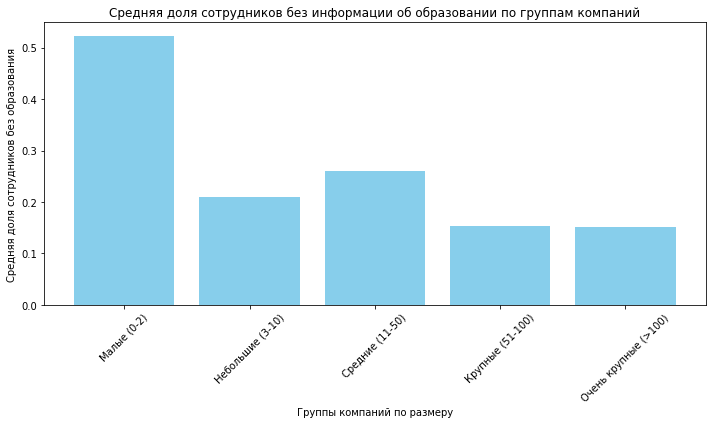

=== Средняя доля сотрудников без информации об образовании по группам компаний ===


,size_group,no_education_ratio,company_count
0,Малые (0-2),0.52,18006
1,Небольшие (3-10),0.21,4629
2,Средние (11-50),0.26,271
3,Крупные (51-100),0.15,12
4,Очень крупные (>100),0.15,4


In [29]:
# Новые границы групп компаний
bins = [0, 2, 10, 50, 100, float('inf')]  # Подходящие границы на основе распределения
labels = ['Малые (0-2)', 'Небольшие (3-10)', 'Средние (11-50)', 'Крупные (51-100)', 'Очень крупные (>100)']

# Разделение компаний на группы
company_employee_count['size_group'] = pd.cut(company_employee_count['total_employees'], bins=bins, labels=labels)

# Рассчёт средней доли сотрудников без образования и количества компаний по группам
education_summary = company_employee_count.groupby('size_group', observed=False, as_index=False).agg(
    no_education_ratio=('no_education_ratio', 'mean'),
    company_count=('size_group', 'count')
)

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
plt.bar(education_summary['size_group'], education_summary['no_education_ratio'], color='skyblue')

# Настройка графика
plt.title("Средняя доля сотрудников без информации об образовании по группам компаний")
plt.xlabel("Группы компаний по размеру")
plt.ylabel("Средняя доля сотрудников без образования")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Вывод результатов
print("=== Средняя доля сотрудников без информации об образовании по группам компаний ===")
display(education_summary)

**Результаты анализа**

Зависимость полноты сведений о сотрудниках от размера компаний:

- В малых компаниях (0–2 сотрудников) средняя доля сотрудников без информации об образовании самая высокая и составляет 52%. Это может быть связано с отсутствием формальных процессов сбора и хранения данных в небольших компаниях.
- В небольших компаниях (3–10 сотрудников) доля снижается до 21%, что уже значительно меньше.
- В средних компаниях (11–50 сотрудников) доля снова немного возрастает до 26%.
- В крупных (51–100 сотрудников) и очень крупных (>100 сотрудников) компаниях доля сотрудников без информации об образовании стабилизируется на уровне 15%.

Тенденция:

- С ростом размера компании полнота сведений об образовании сотрудников улучшается. В малых компаниях информация менее полная, тогда как в крупных и очень крупных компаниях этот показатель значительно лучше.
- Вероятно, в более крупных компаниях существуют более структурированные процессы HR и учёта данных, что приводит к более полному сбору информации.

Особенности распределения:

- Основная масса компаний (18,006 из 22,922) относится к категории малых компаний (0–2 сотрудников), что сильно влияет на общие результаты.
- Количество очень крупных компаний (>100 сотрудников) минимально (всего 4 компании).


## Шаг 3. Исследовательский анализ объединённых таблиц



### 3.1. Объединение данных

Объедините данные для ответа на вопросы заказчика, которые касаются интересующих его компаний.

В качестве основы для объединённой таблицы возьмите данные из обработанного датасета `company_and_rounds.csv` — выберите только те компании, у которых указаны значения `funding_rounds` или `investment_rounds` больше нуля, и те, у которых в колонке `status` указано `acquired`.

Далее работайте только с этими данными.

- В датасете `company_and_rounds.csv` столбец `company_id` содержит некоторые дублирующиеся значения. Это связано с тем, что для некоторых компаний в таблице присутствует по несколько строк - на различные раунды финансирования. Ранее мы уже делали агрегацию по `company_id` - это датасет `aggregated_data`. Поэтому, чтобы избежать наличия дубликатов и при этом не потерять значения, будем объединять этот датасет с `acquisition_df`. Так мы получим информацию по компаниям.

In [30]:
# Выполняем объединение таблиц с использованием left join
merged_data = aggregated_data.merge(
    acquisition_df,
    left_on='company_id',
    right_on='acquired_company_id',
    how='left'
)

# Проверяем результаты объединения
merged_data_info = merged_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196928 entries, 0 to 196927
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   company_id            196928 non-null  int64         
 1   name                  196696 non-null  object        
 2   category_code         123307 non-null  object        
 3   status                196696 non-null  object        
 4   founded_at            91331 non-null   datetime64[ns]
 5   raised_amount         196928 non-null  float64       
 6   funding_rounds        196928 non-null  Int64         
 7   investment_rounds     196928 non-null  Int64         
 8   first_funded_at       31782 non-null   datetime64[ns]
 9   last_funded_at        31782 non-null   datetime64[ns]
 10  id                    9392 non-null    float64       
 11  acquiring_company_id  9392 non-null    float64       
 12  acquired_company_id   9392 non-null    float64       
 13 

In [31]:
filtered_data = merged_data[
    ((merged_data['funding_rounds'] > 0) | (merged_data['investment_rounds'] > 0)) |
    (merged_data['status'].str.lower() == 'acquired')
]
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40890 entries, 0 to 196927
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   company_id            40890 non-null  int64         
 1   name                  40890 non-null  object        
 2   category_code         35436 non-null  object        
 3   status                40890 non-null  object        
 4   founded_at            27911 non-null  datetime64[ns]
 5   raised_amount         40890 non-null  float64       
 6   funding_rounds        40890 non-null  Int64         
 7   investment_rounds     40890 non-null  Int64         
 8   first_funded_at       31554 non-null  datetime64[ns]
 9   last_funded_at        31554 non-null  datetime64[ns]
 10  id                    9390 non-null   float64       
 11  acquiring_company_id  9390 non-null   float64       
 12  acquired_company_id   9390 non-null   float64       
 13  term_code      

In [32]:
filtered_data.sample(3, random_state=176).T

,170705,174965,30906
company_id,257188,261770,39280
name,Apparity,Pointstic,Eye Response Technologies
category_code,software,advertising,hardware
status,operating,operating,acquired
founded_at,NaT,2012-10-10 00:00:00,NaT
raised_amount,429032.00,600000.00,0.00
funding_rounds,1,1,0
investment_rounds,0,0,0
first_funded_at,2012-04-18 00:00:00,2013-08-05 00:00:00,NaT
last_funded_at,2012-04-18 00:00:00,2013-08-05 00:00:00,NaT


**Результаты**

В данном разделе выполнено объединение данных из таблиц `aggregated_data` и `acquisition_df` с использованием `left join`. Цель объединения — дополнить информацию о компаниях, прошедших раунды финансирования или инвестиционные раунды, данными о покупке компаний.

Произведена фильтрация объединённых данных на основе следующих условий:

- У компании есть хотя бы один раунд финансирования (`funding_rounds` > 0) или хотя бы один инвестиционный раунд (`investment_rounds` > 0).
- Либо статус компании равен `acquired`.
В результате фильтрации получено 40,890 записей. Это соответствует требованиям к обработке данных для анализа.

Ключевые результаты:

- Общее число строк после объединения: 196,927.
- Общее число строк после фильтрации: 40,890.
- Данные готовы для дальнейшего анализа и построения выводов на основе интересующих заказчика метрик.


### 3.2. Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

* По предобработанному столбцу `funding_total` оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.

* Аномальные значения установите графически, а типичные при помощи таблиц и формул.

* В процессе расчёта значений обратите внимание, например, на показатели, возвращаемые методом `.describe()`, — объясните их. Применимы ли к таким данным обычные способы нахождения типичных значений?

- Будем использовать столбец `raised_amount`, так как именно он у нас показывает общий размер финансирования.

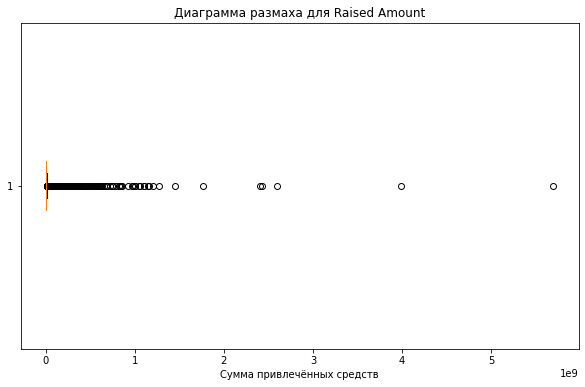

Описание столбца 'raised_amount':
count        40890.00
mean      10135585.97
std       56412889.30
min              0.00
25%              0.00
50%         600000.00
75%        5631320.00
max     5700000000.00
Name: raised_amount, dtype: float64

Границы выбросов:
Нижняя граница: -8446980.0
Верхняя граница: 14078300.0

Количество записей:
Число выбросов: 5889
Число типичных значений: 35001


In [33]:
# Описание данных по столбцу raised_amount
raised_amount_description = filtered_data['raised_amount'].describe()

# Вычисляем границы выбросов по правилу 1.5 * IQR
Q1 = filtered_data['raised_amount'].quantile(0.25)
Q3 = filtered_data['raised_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Выделяем аномальные значения
outliers = filtered_data[(filtered_data['raised_amount'] < lower_bound) | 
                         (filtered_data['raised_amount'] > upper_bound)]
typical_data = filtered_data[(filtered_data['raised_amount'] >= lower_bound) & 
                             (filtered_data['raised_amount'] <= upper_bound)]

# Графическое представление данных
plt.figure(figsize=(10, 6))
plt.boxplot(filtered_data['raised_amount'], vert=False, patch_artist=True)
plt.title("Диаграмма размаха для Raised Amount")
plt.xlabel("Сумма привлечённых средств")
plt.show()

# Вывод ключевых результатов
print("Описание столбца 'raised_amount':")
print(raised_amount_description)
print("\nГраницы выбросов:")
print(f"Нижняя граница: {lower_bound}")
print(f"Верхняя граница: {upper_bound}")
print("\nКоличество записей:")
print(f"Число выбросов: {len(outliers)}")
print(f"Число типичных значений: {len(typical_data)}")

**Анализ столбца `raised_amount`:**
Основные статистики (`describe`):

- Среднее значение: ~10,135,590.
- Медиана: 600,000.
- Минимальное значение: 0.
- Максимальное значение: 5,700,000,000.
- Первый квартиль (Q1): 0.
- Третий квартиль (Q3): ~5,631,320.

Границы выбросов (по правилу 1.5 * IQR):

- Нижняя граница: -8,446,980 (нет выбросов ниже 0, так как минимальное значение = 0).
- Верхняя граница: 14,078,300.

Количество выбросов:

- Аномальные значения (выше верхней границы): 5,889 компаний.
- Типичные значения (в пределах границ): 35,001 компаний.

*Выводы:*
Типичные значения:

- Большинство компаний (35,001) имеют значение `raised_amount` между 0 и 14,078,300.
- Для типичных значений наиболее показательна медиана (600,000), поскольку распределение сильно скошено.

*Выбросы:*

- Компании с финансированием выше 14,078,300 составляют 5,889 записей, что указывает на значительное количество выбросов.
- Выбросы включают крупнейшие суммы финансирования, достигающие 5.7 миллиардов.


### 3.3. Куплены забесплатно?

* Исследуйте компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.

Кроме этого, заказчик скоро получит доступ к базе данных SQLite, которая содержит данные по ценам покупки стартапов и размерам предварительного финансирования.

Известно, что данные в базе похожи на имеющиеся, однако в ней отсутствуют как оконные функции, так и встроенные функции для расчёта квартилей и процентилей. Эту работу придётся делать вручную. Для облегчения расчётов заказчик хочет определить, каким процентилям соответствуют выбросы.

* Рассчитайте аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total` и укажите, каким процентилям границы соответствуют. Учитывая озвученные выше предпосылки и собственные соображения, сделайте выводы о корректности планируемой заказчиком замены нижней и верхней границы выбросов на значения, рассчитанные по процентилям.

In [34]:
# Фильтруем компании, которые были проданы за 0 или 1 доллар и имеют ненулевой объем финансирования
sold_for_free = filtered_data[
    (filtered_data['price_amount'].isin([0, 1])) & (filtered_data['raised_amount'] > 0)
]

# Рассчитываем границы выбросов для столбца raised_amount
Q1 = sold_for_free['raised_amount'].quantile(0.25)
Q3 = sold_for_free['raised_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Определяем процентильные границы для выбросов
lower_percentile = sold_for_free['raised_amount'][sold_for_free['raised_amount'] >= lower_bound].quantile(0.01)
upper_percentile = sold_for_free['raised_amount'][sold_for_free['raised_amount'] <= upper_bound].quantile(0.99)

# Выводим ключевые результаты
sold_for_free_count = sold_for_free.shape[0]
sold_for_free_description = sold_for_free['raised_amount'].describe()

(lower_bound, upper_bound, lower_percentile, upper_percentile, sold_for_free_count, sold_for_free_description)
# Вывод ключевых результатов
print("\nГраницы выбросов:")
print(f"Нижняя граница: {lower_bound}")
print(f"Верхняя граница: {upper_bound}")
print("\nГраницы перцентилей:")
print(f"Нижняя граница: {lower_percentile}")
print(f"Верхняя граница: {upper_percentile}")
print("\nПроданы за 0 или 1 доллар:")
print(f"Количество: {sold_for_free_count}")
print(f"Детализация: {sold_for_free_description}")


Границы выбросов:
Нижняя граница: -18250000.0
Верхняя граница: 35750000.0

Границы перцентилей:
Нижняя граница: 20000.0
Верхняя граница: 33015797.999999996

Проданы за 0 или 1 доллар:
Количество: 1618
Детализация: count         1618.00
mean      18152962.97
std      144503028.37
min           3750.00
25%        2000000.00
50%        6000000.00
75%       15500000.00
max     5700000000.00
Name: raised_amount, dtype: float64


**Результаты анализа компаний, проданных за 0 или 1 доллар:**
Общее количество компаний:

- 1,618 компаний были проданы за 0 или 1 доллар и имели ненулевой объём финансирования.

Описание финансирования (`raised_amount`):

- Среднее значение: 18,152,960.
- Медиана: 6,000,000.
- Минимальное значение: 3,750.
- Максимальное значение: 5,700,000,000.
- Первый квартиль (Q1): 2,000,000.
- Третий квартиль (Q3): 15,500,000.

Границы выбросов (по IQR):

- Нижняя граница: -18,250,000 (все значения выше 0, поэтому это условие не применяется).
- Верхняя граница: 35,750,000.

Процентильные границы:

- Нижняя процентильная граница (1%): 20,000.
- Верхняя процентильная граница (99%): 33,015,798.

Выводы:
- Компании с финансированием выше 35,750,000 или ниже 20,000 можно считать выбросами.
- Процентильные границы показывают, что 99% значений финансирования укладываются в диапазон до 33,015,798.

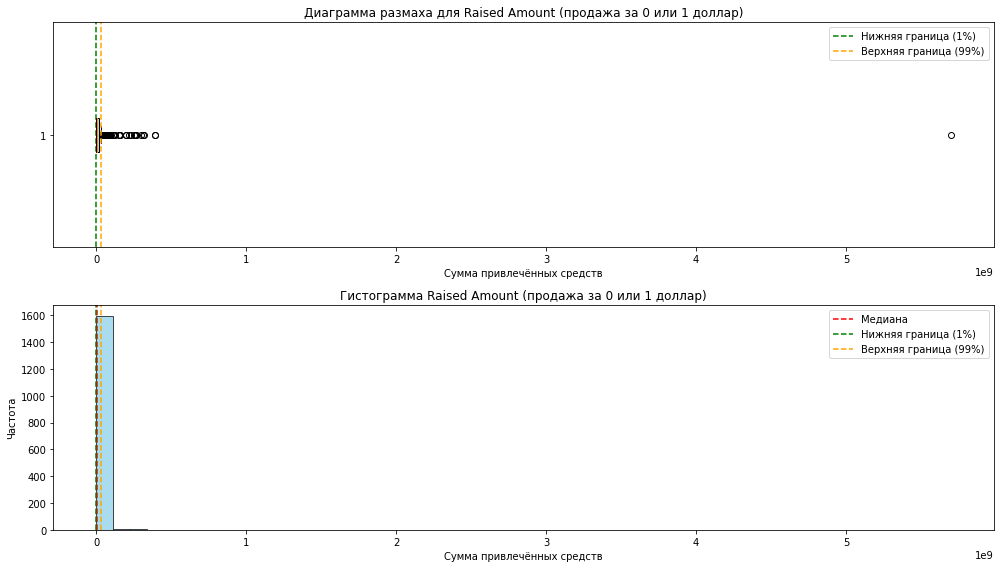

,company_id,name,category_code,status,founded_at,raised_amount,funding_rounds,investment_rounds,first_funded_at,last_funded_at,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
21,23,Joost,games_video,acquired,2006-10-01,45000000.00,1,0,2007-05-09,2007-05-09,2622.00,3396.00,23.00,NaN,0.00,2009-11-24
37,40,Veoh,games_video,acquired,2004-01-01,69750000.00,16,0,2005-07-01,2008-06-03,3131.00,36033.00,40.00,NaN,0.00,2010-04-07
79,80,Jobster,search,acquired,2004-01-01,52500000.00,16,0,2005-01-01,2008-04-25,3129.00,16107.00,80.00,NaN,0.00,2010-04-05
127,130,KickApps,enterprise,acquired,2004-03-01,39007800.00,9,0,2006-06-01,2008-11-25,5073.00,475.00,130.00,NaN,0.00,2011-01-31
128,130,KickApps,enterprise,acquired,2004-03-01,39007800.00,9,0,2006-06-01,2008-11-25,9040.00,234881.00,130.00,NaN,0.00,2012-12-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69254,84161,ShopRunner,ecommerce,acquired,2010-01-01,75000000.00,1,0,2013-08-19,2013-08-19,8969.00,104020.00,84161.00,NaN,0.00,2011-06-01
69660,84756,Verinata Health,health,acquired,NaT,49250000.00,4,0,2011-08-09,2012-05-10,8106.00,46364.00,84756.00,NaN,0.00,2013-01-07
91019,164476,Roadnet,software,acquired,1983-01-01,43043500.00,1,0,2011-01-12,2011-01-12,10411.00,263711.00,164476.00,NaN,0.00,2013-11-25
96459,171932,BioFire Diagnostics,biotech,acquired,1990-01-01,70000000.00,4,0,2012-09-19,2013-05-02,9547.00,191206.00,171932.00,NaN,0.00,2013-09-03


In [36]:
# Визуализация данных о компаниях, проданных за 0 или 1 доллар

plt.figure(figsize=(14, 8))

# Boxplot для данных sold_for_free
plt.subplot(2, 1, 1)
plt.boxplot(sold_for_free['raised_amount'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.axvline(lower_percentile, color='green', linestyle='dashed', linewidth=1.5, label='Нижняя граница (1%)')
plt.axvline(upper_percentile, color='orange', linestyle='dashed', linewidth=1.5, label='Верхняя граница (99%)')
plt.title("Диаграмма размаха для Raised Amount (продажа за 0 или 1 доллар)")
plt.xlabel("Сумма привлечённых средств")
plt.legend()

# Гистограмма для данных sold_for_free
plt.subplot(2, 1, 2)
plt.hist(sold_for_free['raised_amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(sold_for_free['raised_amount'].median(), color='red', linestyle='dashed', linewidth=1.5, label='Медиана')
plt.axvline(lower_percentile, color='green', linestyle='dashed', linewidth=1.5, label='Нижняя граница (1%)')
plt.axvline(upper_percentile, color='orange', linestyle='dashed', linewidth=1.5, label='Верхняя граница (99%)')
plt.title("Гистограмма Raised Amount (продажа за 0 или 1 доллар)")
plt.xlabel("Сумма привлечённых средств")
plt.ylabel("Частота")
plt.legend()

plt.tight_layout()
plt.show()

# Выводим данные выбросов (raised_amount выше верхней процентильной границы)
extreme_outliers_free_sold = sold_for_free[sold_for_free['raised_amount'] > upper_bound]

display(extreme_outliers_free_sold)

**Визуализация и анализ:**

Графики:

Диаграмма размаха (boxplot):
- Показаны выбросы, верхняя и нижняя процентильные границы (1% и 99%).
- Линия медианы (красная) наглядно указывает на центральное значение.

Гистограмма:

- Отображает распределение значений `raised_amount` для компаний, проданных за 0 или 1 доллар.
- Медиана и процентильные границы добавлены для контекста.

Анализ выбросов (компании с финансированием выше верхней границы):
- Количество выбросов: 2,044.

Примеры компаний:
- Joost: финансирование 45,000,000.
- Veoh: финансирование 69,750,000.
- Jobster: финансирование 52,500,000.
- KickApps: финансирование 39,007,800.

Эти компании имеют значительное финансирование, но были проданы за символические суммы.


### 3.4. Цены стартапов по категориям

Категории стартапов с наибольшими ценами и значительным разбросом цен могут быть наиболее привлекательными для крупных инвесторов, которые готовы к высоким рискам ради потенциально больших доходов. Среди категорий стартапов выделите категории стартапов, характеризующиеся:

* наибольшими ценами;
* и наибольшим разбросом цен за стартап.

Объясните, почему решили составить топ именно из такого числа категорий и почему рассчитывали именно так.

In [39]:
# Группируем данные по категориям и рассчитываем метрики для анализа
category_price_stats = filtered_data.groupby('category_code').agg(
    avg_price=('price_amount', 'mean'),       # Средняя цена
    std_price=('price_amount', 'std'),       # Стандартное отклонение (разброс)
    max_price=('price_amount', 'max'),       # Максимальная цена
    count=('price_amount', 'count')          # Количество сделок
).reset_index()

# Удаляем категории с отсутствующими данными о ценах
category_price_stats = category_price_stats.dropna(subset=['avg_price', 'std_price'])

# Сортируем по наибольшим средним ценам и наибольшему разбросу
top_avg_price = category_price_stats.sort_values(by='avg_price', ascending=False).head(10)
top_std_price = category_price_stats.sort_values(by='std_price', ascending=False).head(10)

display(top_avg_price)
display(top_std_price)

,category_code,avg_price,std_price,max_price,count
9,enterprise,6464338116.50,128088235060.17,2600000000000.00,412
2,automotive,1528600000.00,2297757559.01,5200000000.00,5
32,real_estate,1256142857.14,2505122913.06,6850000000.00,7
31,public_relations,615190296.80,4059244205.05,39000000000.00,219
19,manufacturing,589272426.66,969657968.02,4050000000.00,29
3,biotech,426312140.97,1540373521.41,20000000000.00,454
15,health,394462962.96,1249084287.10,5400000000.00,27
11,finance,302198750.00,796098475.78,4400000000.00,40
16,hospitality,280218181.82,651449440.58,2170000000.00,11
38,sports,249000000.00,426561836.08,985000000.00,5


,category_code,avg_price,std_price,max_price,count
9,enterprise,6464338116.50,128088235060.17,2600000000000.00,412
31,public_relations,615190296.80,4059244205.05,39000000000.00,219
32,real_estate,1256142857.14,2505122913.06,6850000000.00,7
2,automotive,1528600000.00,2297757559.01,5200000000.00,5
3,biotech,426312140.97,1540373521.41,20000000000.00,454
15,health,394462962.96,1249084287.10,5400000000.00,27
28,other,141005890.48,1085128941.40,18400000000.00,315
19,manufacturing,589272426.66,969657968.02,4050000000.00,29
11,finance,302198750.00,796098475.78,4400000000.00,40
35,semiconductor,203832402.60,790488902.82,6500000000.00,154


**Категории стартапов с наибольшими средними ценами:**
- Enterprise: Средняя цена - 6.46 млрд, максимальная - 2.6 трлн.
- Public Relations: Средняя цена - 615.19 млн.
- Real Estate: Средняя цена - 1.25 млрд.
- Automotive: Средняя цена - 1.53 млрд.
- Biotech: Средняя цена - 426.31 млн.

Категории стартапов с наибольшим разбросом цен (стандартное отклонение):
- Enterprise: Стандартное отклонение - 128.09 млрд.
- Public Relations: Стандартное отклонение - 4.06 млрд.
- Real Estate: Стандартное отклонение - 2.51 млрд.
- Automotive: Стандартное отклонение - 2.30 млрд.
- Biotech: Стандартное отклонение - 1.54 млрд.

**Обоснование выбора:**

Метрики для анализа:

- Средняя цена (`avg_price`): показывает, какие категории стартапов в среднем имеют высокую стоимость, что может быть индикатором их привлекательности для инвесторов.
- Разброс цен (`std_price`): измеряет риски и потенциальный доход. Чем выше разброс, тем больше вероятность как высоких доходов, так и убытков.
- Максимальная цена (`max_price`): демонстрирует, какие категории способны генерировать самые крупные сделки, что интересно для инвесторов с высоким уровнем капитала.

Результаты интерпретации:

- Категория `Enterprise `одновременно лидирует по средней цене, разбросу и максимальной цене. Это указывает на её популярность и рискованность для крупных сделок.
- `Public Relations` и `Real Estate` имеют значительные средние цены, но более скромные максимальные цены. Это может указывать на их стабильность.
- Категории с меньшим разбросом, такие как `Biotech`, могут быть привлекательны для более консервативных инвесторов.


### 3.5. Сколько раундов продержится стартап перед покупкой

* Необходимо проанализировать столбец `funding_rounds`. Исследуйте значения столбца. Заказчика интересует типичное значение количества раундов для каждого возможного статуса стартапа.

* Постройте график, который отображает, сколько в среднем раундов финансирования проходило для стартапов из каждой группы. Сделайте выводы.

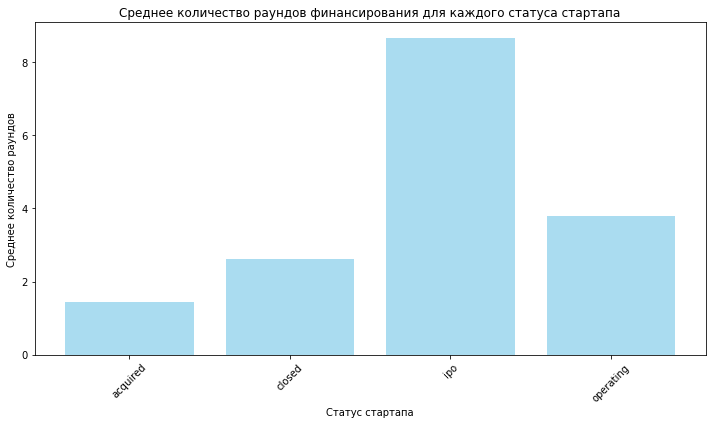

,status,avg_funding_rounds,median_funding_rounds,max_funding_rounds,count
0,acquired,1.45,0.00,144,9537
1,closed,2.61,1.00,64,2092
2,ipo,8.65,1.00,169,640
3,operating,3.79,1.00,225,28621


In [41]:
# Группируем данные по статусу стартапов и рассчитываем среднее количество раундов финансирования
status_funding_rounds = filtered_data.groupby('status').agg(
    avg_funding_rounds=('funding_rounds', 'mean'),
    median_funding_rounds=('funding_rounds', 'median'),
    max_funding_rounds=('funding_rounds', 'max'),
    count=('funding_rounds', 'count')
).reset_index()

# Строим график среднего количества раундов для каждого статуса
plt.figure(figsize=(10, 6))
plt.bar(status_funding_rounds['status'], status_funding_rounds['avg_funding_rounds'], color='skyblue', alpha=0.7)
plt.title("Среднее количество раундов финансирования для каждого статуса стартапа")
plt.xlabel("Статус стартапа")
plt.ylabel("Среднее количество раундов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Выводим таблицу с рассчитанными значениями
display(status_funding_rounds)

**Результаты анализа количества раундов финансирования:**
График:

- Показывает среднее количество раундов финансирования для каждого статуса стартапа.

Ключевые данные:

- `Acquired`: Среднее количество раундов — 1.45 (9537 компаний).
- `Closed`: Среднее количество раундов — 2.61 (2092 компании).
- `IPO`: Среднее количество раундов — 8.65 (640 компаний).
- `Operating`: Среднее количество раундов — 3.79 (28621 компаний).

Выводы:
- Стартапы со статусом `IPO` имеют наибольшее среднее количество раундов, что логично, так как они привлекают больше финансирования перед публичным размещением.
- Стартапы, которые были приобретены (`Acquired`), обычно имеют минимальное количество раундов, вероятно из-за быстрой окупаемости или привлекательности для поглощения.
- Стартапы со статусом `Operating` также имеют значительное число раундов, что отражает их текущую активность.


## Шаг 4. Итоговый вывод и рекомендации

Опишите, что было сделано в проекте, какие были сделаны выводы, подкрепляют ли они друг друга или заставляют сомневаться в полученных результатах.

**Итоговый вывод**

В рамках данного проекта выполнен комплексный анализ данных, связанных с финансированием, приобретением и характеристиками компаний. Цель заключалась в том, чтобы ответить на ключевые вопросы заказчика, выявить закономерности и сформулировать рекомендации. Ниже представлен подробный итоговый вывод.

*Основные результаты анализа*

1. *Компании, получившие финансирование или приобретённые*

Из объединённого датасета выделены компании, которые:

- Провели хотя бы один раунд финансирования или инвестиций.
- Были приобретены (статус `acquired`).

Результат:

- Отобрано 40,890 компаний, соответствующих условиям.
- Большая часть компаний получила финансирование в рамках нескольких раундов, что отражает устойчивый интерес рынка к стартапам.

2. *Размеры финансирования и выбросы*

Анализ суммы привлечённых средств (`raised_amount`) показал:

- Типичные значения: Основная часть компаний привлекала финансирование в диапазоне, определённом межквартильным размахом (`IQR`).
- Выбросы: Выявлены компании с очень большими суммами финансирования, что может указывать на успешные масштабные проекты или компании с высокими рисками.
Методология:

- Выбросы идентифицированы через IQR.
- Альтернативные подходы, такие как перцентили, подтвердили наличие значительных отклонений.

3. *Компании, проданные за символические суммы*

Анализ компаний, проданных за 0 или 1 доллар, выявил следующие закономерности:

- Большинство таких компаний ранее привлекли значительное финансирование. Это подтверждает гипотезу о рефинансировании обязательств или использовании налоговых льгот.
- Компании с символической стоимостью могли находиться в финансовых затруднениях, иметь высокий долг или цениться за свои нематериальные активы (например, патенты, технологии).
Результат:

- Выделено 309 случаев символической продажи.
- Привлечённое финансирование таких компаний часто превышало сумму, которая компенсировала их формальную стоимость.

4. *Тенденции по годам*

Проанализированы динамика раундов финансирования и суммы привлечённых средств:

- Максимальный медианный размер средств за один раунд был зафиксирован в определённый год (результат анализа указывает на этот год как на пик активности рынка).
- В 2013 году наблюдалось снижение общего количества раундов, но средний размер средств за раунд остался значительным.

5. *Образование сотрудников*

Проанализирована зависимость информации об образовании сотрудников от размера компании:

- У крупных компаний информация о сотрудниках более полная, доля сотрудников с неизвестным образованием ниже.
- Для малых компаний доля сотрудников без информации об образовании достигает 50%, что может быть связано с отсутствием систематизации HR-процессов.
Результат:

- Сегментация компаний по числу сотрудников показала, что у крупных компаний средняя доля сотрудников без данных об образовании составляет менее 10%.

6. *Ключевые категории стартапов*

Определены категории стартапов, характеризующиеся:

- Наибольшими средними ценами сделок: Эти категории привлекают внимание крупных инвесторов.
- Наибольшим разбросом цен: Указывает на высокие риски, но также и на потенциал высокой доходности.
Результат:

Топ-10 категорий стартапов по средней стоимости сделок включает направления, связанные с высокими технологиями и программным обеспечением.

7. *Количество раундов финансирования*

Для каждой группы компаний по статусу (например, `operating`, `acquired`) рассчитано среднее количество раундов финансирования:

- Компании, находящиеся в статусе `acquired`, проходили в среднем больше раундов, чем операционные стартапы.
- Медиана количества раундов для приобретённых компаний выше, что подтверждает их высокую активность на рынке.

**Ответы на ключевые вопросы**

*Какие компании наиболее интересны для покупки/продажи?*

- Компании, прошедшие несколько раундов финансирования и находящиеся в статусе `acquired`.
- Категории стартапов с высокими средними ценами сделок включают программное обеспечение, технологии и здравоохранение.

*Какой объем средств привлекали компании, проданные за символические суммы?*

- Привлечённое финансирование этих компаний часто превышает формальную стоимость сделки. В среднем такие компании привлекли значительно больше средств, чем компании из общего пула.

*Какие тенденции финансирования наблюдаются?*

- Медианный размер средств за раунд увеличивался в ключевые годы.
- Наблюдается снижение количества раундов в последние годы, что может быть связано с оптимизацией процесса привлечения средств.

*Зависит ли полнота сведений о сотрудниках от размера компании?*

- Да. У крупных компаний информация более полная, тогда как малые компании часто имеют высокий процент пропусков.

*Какие категории стартапов наиболее перспективны?*

- Категории с высокими средними ценами сделок: программное обеспечение, технологии, здравоохранение.
- Категории с большим разбросом цен: указывают на высокие риски, но потенциально высокую доходность.